# Bank Marketing Classification
The aim of the analysis is to explore, prepare, and model the Bank Marketing dataset in order to predict whether a client will subscribe to a term deposit (y). This notebook implements a supervised classification workflow for the UCI Bank Marketing dataset.

The notebook follows an analytics workflow: data examination, data cleaning and preprocessing, model development, and model evaluation. Multiple classification models will be compared using appropriate performance metrics, with particular attention given to class imbalance and the suitability of variables used for prediction.

Dataset: https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing

## References
https://docs.1010data.com/Tutorials/MachineLearningExamples/BankMarketingDataSet.html
https://rstudio-pubs-static.s3.amazonaws.com/1346881_08b338774fe240ec8bb67153fbf45ccc.html

## Libraries and Tools used
1. [Matplotlib ](https://matplotlib.org) - For plotting graphs.
0. [Numpy](https://numpy.org) - Calculations
0. [Pandas](https://pandas.pydata.org) - Dataframes and data manipulation
0. [Imbalanced-learn](https://imbalanced-learn.org/stable/) - Pipeline, SMOTE
0. [Scikit-learn](https://scikit-learn.org/stable/) - Data Analysis functions
0. [Jupyter](https://jupyter.org) - Notebook Tool

In [35]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

## Data Exploration
Examine the different aspects of the dataset in order to develop a general insight into the data.

### Data Overview

- Each row represents a contact record from the bank marketing campaign
- The same client may appear in multiple rows because more than one contact was sometimes required.
- There are 41188 rows and 21 columns

In [36]:
# Importing dataset
dataset = pd.read_csv('dataset/bank-additional-full.csv', sep=';')
dataset

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [37]:
# View first 5 rows of the dataset
dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [38]:
# View the number of rows and columns in the dataset.
dataset.shape


(41188, 21)

### Data Quality Checks
#### Types
- The dataset contains varied types, `int`, `str`, and `float`, which will have to be managed before modeling.
- There are a 11 categorical columns, including the target: `'job', 'marital','education','default','housing','loan','contact','month','day_of_week','poutcome','y'`.
- Numerical values show some outliers, for example, `pdays` has `999` for the all greater quartiles.
#### Duplicates
- There are a 12 duplicate rows. In this case, they can be confirmed as duplicates as many of the column values are specific and  they match across all columns.
- Additionally, as the number is small, their removal has nearly no impact on the proportion of the target value with only one of them being positive.
#### Missing Values
- The dataset reports no missing values, however this is incorrect as, upon examination, there are placeholder values such as `unknown` or `999` in use.
- `nonexistent` must also be encoded appropriately for modelling.
- No negative, invalid, numeric values exist

In [39]:
# View the count and data type of each column in the dataset.
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [40]:
# View the statistical summary of the dataset.
dataset.nunique().sort_values()

y                    2
contact              2
default              3
housing              3
loan                 3
poutcome             3
marital              4
day_of_week          5
education            8
previous             8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

In [41]:
# View the statistical summary of the dataset.
dataset.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [42]:
# Explore catgorical features in the dataset.
categorical_columns = dataset.select_dtypes(exclude=['number']).columns.tolist()
categorical_columns


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [43]:
# Check for duplicates
duplicates = dataset.duplicated().sum()
duplicates

np.int64(12)

In [44]:
# Examine duplicates.
dataset[dataset.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [45]:
# Examine proportion of dataset with duplicates against without duplicates.
(dataset['y'] == 'yes').mean(), (dataset.drop_duplicates()['y'] == 'yes').mean()

(np.float64(0.11265417111780131), np.float64(0.11266271614532737))

In [46]:
# Check for missing values in the dataset.
dataset.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [47]:
# Check for 'unknown' values in the dataset.
unknown_summary = (dataset.select_dtypes(include=['object', 'str']) == 'unknown').sum()
unknown_summary

job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

In [48]:
# Check for 'nonexistent' values in the 'poutcome' column.
nonexistent_count = (dataset['poutcome'] == 'nonexistent').sum()
nonexistent_count

np.int64(35563)

In [49]:
# Check for 999 values in the 'pdays' column.
pdays_summary = dataset['pdays'].eq(999).sum()
pdays_summary

np.int64(39673)

In [50]:
# Check for negative or zero values in numeric columns.
numeric_validity = pd.Series({
    'age <= 0': (dataset['age'] <= 0).sum(),
    'duration < 0': (dataset['duration'] < 0).sum(),
    'campaign <= 0': (dataset['campaign'] <= 0).sum(),
    'pdays < 0': (dataset['pdays'] < 0).sum(),
    'previous < 0': (dataset['previous'] < 0).sum(),
})
numeric_validity

age <= 0         0
duration < 0     0
campaign <= 0    0
pdays < 0        0
previous < 0     0
dtype: int64

### Target Overview
- The target value is a minority value in an imbalanced dataset.
- There are 36548 no values to 4640 y values, or ~89% to ~11% respectively.

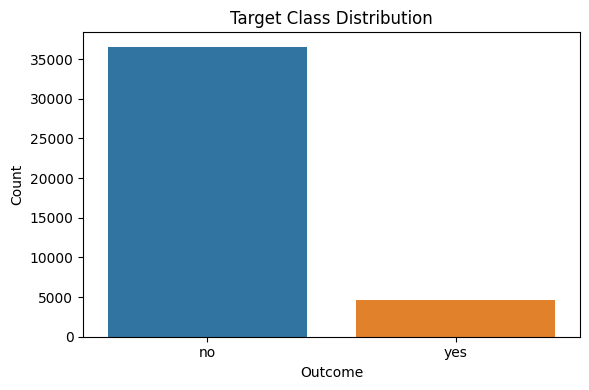

In [51]:
# Check for dataset balance. Target value is imbalanced.
print(dataset['y'].value_counts(normalize=True))
print(dataset['y'].value_counts())

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64
y
no     36548
yes     4640
Name: count, dtype: int64


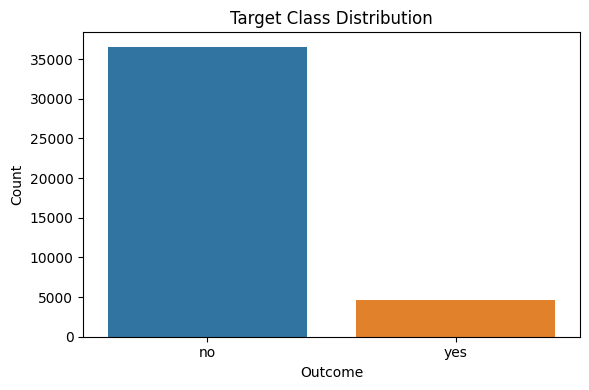

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=dataset, x='y', hue='y', dodge=False, ax=ax)
ax.set_title('Target Class Distribution')
ax.set_xlabel('Outcome')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Data Cleaning
Prepare the data for training

### Duplicates and Missing Values
- Duplicates were removed.
- The `999` placeholder value in pdays was separated into two values: a new `previously_contacted` column with either `False` or `True`; and `NaN` in its own column to more accurately reflect that there is no value.
- The `unknown` value is present across numerous features. This is recognised and will be handled as its own category in preprocessing as it is not the representation of a missing value, but a category in itself.
- Likewise, the `nonexistent` value in the `poutcome` column will be encoded correctly in preprocessing.

In [53]:
# Create a copy, confirm the rows.
df_to_clean = dataset.copy()
df_to_clean.shape

(41188, 21)

In [54]:
# Drop duplicates, confirm the number of rows after dropping duplicates.
df_to_clean = df_to_clean.drop_duplicates().reset_index(drop=True)
df_to_clean.shape

(41176, 21)

In [55]:
# Handle all 999 values in the 'pdays' column by creating a new column.
df_to_clean['previously_contacted'] = np.where(df_to_clean['pdays'] == 999, False, True)
df_to_clean['previously_contacted'].value_counts()

previously_contacted
False    39661
True      1515
Name: count, dtype: int64

In [56]:
# Replace 999 values in 'pdays' column with NaN to indicate missing values.
df_to_clean['pdays'] = df_to_clean['pdays'].replace(999, np.nan).astype('Int64')

In [57]:
df_to_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,<NA>,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False


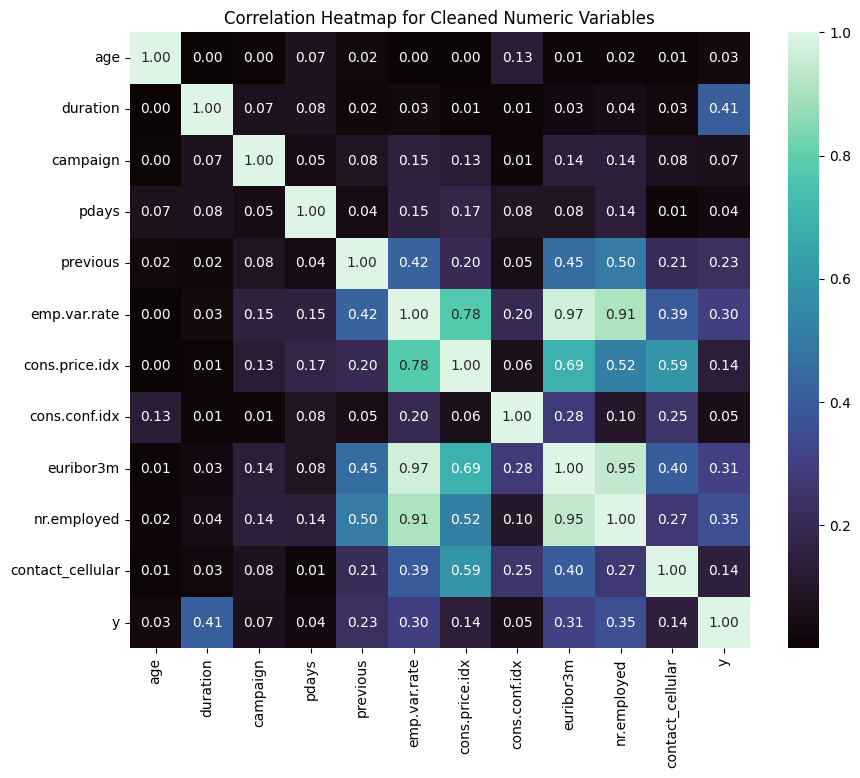

In [64]:
# turn the values into integers for correlation analysis.
corr_view = df_to_clean.copy()
corr_view['contact_cellular'] = corr_view['contact'].eq('cellular').astype(int)
corr_view['y'] = corr_view['y'].map({'no':0, 'yes':1})

# correlation heatmap for numeric variables.
corr_df = corr_view[
    [
        'age', 'duration', 'campaign', 'pdays', 'previous',
        'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
        'euribor3m', 'nr.employed', 'contact_cellular', 'y'
    ]
].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(np.abs(corr_df), annot=True, fmt='.2f', cmap='mako')
plt.title('Correlation Heatmap for Cleaned Numeric Variables')
plt.show()


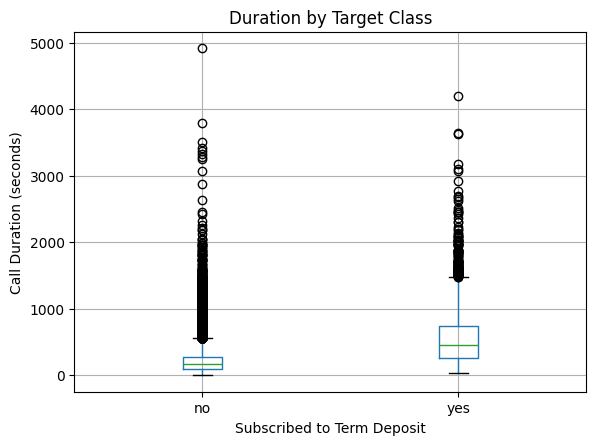

In [ ]:
df_to_clean.boxplot(column='duration', by='y')
plt.title('Duration by Target Class')
plt.suptitle('')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Call Duration (seconds)')
plt.show()

In [73]:
df_to_clean.groupby('y')['duration'].describe()[['mean', '50%', 'std', 'min', 'max']]

,mean,50%,std,min,max
y,,,,,
no,220.868079,164.0,207.116178,0.0,4918.0
yes,553.256090,449.0,401.190736,37.0,4199.0


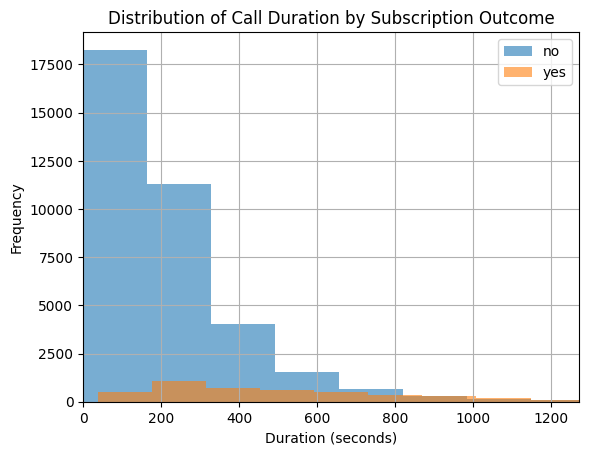

In [76]:
x_max = df_to_clean['duration'].quantile(0.99)

df_to_clean[df_to_clean['y'] == 'no']['duration'].hist(alpha=0.6, bins=30, label='no')
df_to_clean[df_to_clean['y'] == 'yes']['duration'].hist(alpha=0.6, bins=30, label='yes')

plt.xlim(0, x_max)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Call Duration by Subscription Outcome')
plt.legend()
plt.show()